In [26]:
import pandas as pd
df = pd.read_csv('merged_financial_data.csv')
print('CSV file loaded successfully into DataFrame named `df`.')
print(df.head())

CSV file loaded successfully into DataFrame named `df`.
         Date      Ticker    Open    High     Low   Close  Adj Close   Volume  \
0  2025-09-01    adanient  2259.0  2288.0  2252.1  2284.2    2284.20   425639   
1  2025-09-01  adaniports  1318.3  1338.5  1316.1  1335.3    1335.30   983914   
2  2025-09-01  apollohosp  7595.5  7684.5  7595.5  7671.5    7661.33   255894   
3  2025-09-01  asianpaint  2518.0  2577.8  2515.1  2570.2    2566.20  1314833   
4  2025-09-01    axisbank  1047.6  1064.0  1047.6  1061.5    1061.50  3190426   

                                       cleaned_title  neg_sentiment_window  \
0  strong q1 gdp number drive market higher huge ...              0.145715   
1  strong q1 gdp number drive market higher huge ...              0.145715   
2  strong q1 gdp number drive market higher huge ...              0.145715   
3  strong q1 gdp number drive market higher huge ...              0.145715   
4  strong q1 gdp number drive market higher huge ...              0

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Enumerate the 'Ticker' column
df['ticker_enumerated'], unique_tickers = pd.factorize(df['Ticker'])

# Scale the enumerated 'Ticker' values between 0 and 1
scaler = MinMaxScaler()
df['ticker_scaled'] = scaler.fit_transform(df[['ticker_enumerated']])

print("Enumerated Ticker values and scaled values created successfully.")
print(df[['Ticker', 'ticker_enumerated', 'ticker_scaled']].head())

Enumerated Ticker values and scaled values created successfully.
       Ticker  ticker_enumerated  ticker_scaled
0    adanient                  0       0.000000
1  adaniports                  1       0.020833
2  apollohosp                  2       0.041667
3  asianpaint                  3       0.062500
4    axisbank                  4       0.083333


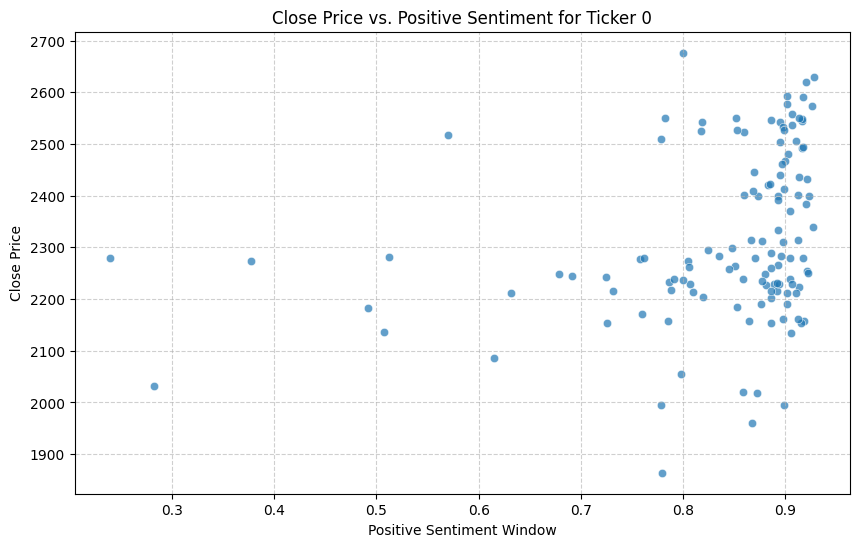

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for ticker_enumerated == 0
df_filtered = df[df['ticker_enumerated'] == 0]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pos_sentiment_window', y='Close', data=df_filtered, alpha=0.7)
plt.title('Close Price vs. Positive Sentiment for Ticker 0')
plt.xlabel('Positive Sentiment Window')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Feature Engineering: Creating Lagged Features and Target Variable

To predict the 11th day's closing price from 10 days of input, we need to create lagged features for each ticker. This involves shifting the data to create columns representing past values and a target column representing the future value we want to predict.

In [29]:
# Sort the DataFrame by Ticker and Date to ensure correct lagging
df = df.sort_values(by=['Ticker', 'Date'])

# Group by Ticker and create lagged features
# We'll create lags for 'Close' price and 'pos_sentiment_window'
features = ['Close', 'pos_sentiment_window', 'neg_sentiment_window', 'neu_sentiment_window', 'Open', 'High', 'Low', 'Volume']

# Create lagged features for the past 10 days
for feature in features:
    for i in range(1, 11):
        df[f'{feature}_lag_{i}'] = df.groupby('Ticker')[feature].shift(i)

# Create the target variable: 'Close' price for the 11th day (shift -1)
df['target_close'] = df.groupby('Ticker')['Close'].shift(-1)

# Drop rows with NaN values resulting from lagging
# These NaNs occur at the beginning of each ticker's data due to lags,
# and at the end due to the future target variable.
df_prepared = df.dropna()

print("Lagged features and target variable created successfully.")
print(df_prepared[['Ticker', 'Date', 'Close', 'pos_sentiment_window', 'Close_lag_1', 'Close_lag_10', 'target_close']].head())

Lagged features and target variable created successfully.
       Ticker        Date   Close  pos_sentiment_window  Close_lag_1  \
490  adanient  2025-09-15  2383.4              0.919802       2392.0   
539  adanient  2025-09-16  2399.4              0.872696       2383.4   
588  adanient  2025-09-17  2402.0              0.859501       2399.4   
637  adanient  2025-09-18  2402.0              0.912408       2402.0   
686  adanient  2025-09-19  2524.0              0.859203       2402.0   

     Close_lag_10  target_close  
490        2284.2        2399.4  
539        2274.2        2402.0  
588        2288.7        2402.0  
637        2278.8        2524.0  
686        2281.4        2629.5  


In [30]:
print(df_prepared.columns.tolist())
print(df_prepared.shape)

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'cleaned_title', 'neg_sentiment_window', 'neu_sentiment_window', 'pos_sentiment_window', 'ticker_enumerated', 'ticker_scaled', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6', 'Close_lag_7', 'Close_lag_8', 'Close_lag_9', 'Close_lag_10', 'pos_sentiment_window_lag_1', 'pos_sentiment_window_lag_2', 'pos_sentiment_window_lag_3', 'pos_sentiment_window_lag_4', 'pos_sentiment_window_lag_5', 'pos_sentiment_window_lag_6', 'pos_sentiment_window_lag_7', 'pos_sentiment_window_lag_8', 'pos_sentiment_window_lag_9', 'pos_sentiment_window_lag_10', 'neg_sentiment_window_lag_1', 'neg_sentiment_window_lag_2', 'neg_sentiment_window_lag_3', 'neg_sentiment_window_lag_4', 'neg_sentiment_window_lag_5', 'neg_sentiment_window_lag_6', 'neg_sentiment_window_lag_7', 'neg_sentiment_window_lag_8', 'neg_sentiment_window_lag_9', 'neg_sentiment_window_lag_10', 'neu_sentiment_window_lag_1', 'neu_sentiment_w

### Data Splitting (Train, Validation, Test)

Now we will split the data into training, validation, and test sets. Since this is time-series data, it's crucial to perform the split chronologically to avoid data leakage. We'll use an 80/10/10 ratio for train/validation/test.

In [31]:
import numpy as np

# Determine split points based on time
# First, convert 'Date' column to datetime objects if not already
df_prepared = df_prepared.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
df_prepared['Date'] = pd.to_datetime(df_prepared['Date'])

# Get unique dates and sort them
dates = df_prepared['Date'].unique()
dates = np.sort(dates) # Fixed: Use np.sort for DatetimeArray

# Calculate split indices
total_samples = len(dates)
train_split_idx = int(total_samples * 0.8)
val_split_idx = int(total_samples * 0.9)

train_date_end = dates[train_split_idx - 1]
val_date_end = dates[val_split_idx - 1]

# Split the data chronologically
train_df = df_prepared[df_prepared['Date'] <= train_date_end]
val_df = df_prepared[(df_prepared['Date'] > train_date_end) & (df_prepared['Date'] <= val_date_end)]
test_df = df_prepared[df_prepared['Date'] > val_date_end]

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Test data shape: {test_df.shape}")

print("Data split into training, validation, and test sets successfully.")

Training data shape: (4459, 95)
Validation data shape: (539, 95)
Test data shape: (588, 95)
Data split into training, validation, and test sets successfully.


In [32]:
# Define the features (X) and target (y)

# Features to include: all lagged features, original numerical features, and ticker_scaled
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', # Original numerical features, as current day's values are part of the 11-day window
    'neg_sentiment_window', 'neu_sentiment_window', 'pos_sentiment_window',
    'ticker_scaled'
]

# Add all lagged features (lag 1 to 10 for each of the original features)
lag_features_base = ['Close', 'pos_sentiment_window', 'neg_sentiment_window', 'neu_sentiment_window', 'Open', 'High', 'Low', 'Volume']
for base_feature in lag_features_base:
    for i in range(1, 11):
        feature_cols.append(f'{base_feature}_lag_{i}')

target_col = 'target_close'

# Prepare X and y for train, validation, and test sets
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Feature and target sets created successfully.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Feature and target sets created successfully.
X_train shape: (4459, 89), y_train shape: (4459,)
X_val shape: (539, 89), y_val shape: (539,)
X_test shape: (588, 89), y_test shape: (588,)


In [33]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns to be scaled (excluding sentiments and ticker_scaled as they are already in range 0-1)
columns_to_scale = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6', 'Close_lag_7', 'Close_lag_8', 'Close_lag_9', 'Close_lag_10',
    'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6', 'Open_lag_7', 'Open_lag_8', 'Open_lag_9', 'Open_lag_10',
    'High_lag_1', 'High_lag_2', 'High_lag_3', 'High_lag_4', 'High_lag_5', 'High_lag_6', 'High_lag_7', 'High_lag_8', 'High_lag_9', 'High_lag_10',
    'Low_lag_1', 'Low_lag_2', 'Low_lag_3', 'Low_lag_4', 'Low_lag_5', 'Low_lag_6', 'Low_lag_7', 'Low_lag_8', 'Low_lag_9', 'Low_lag_10',
    'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_4', 'Volume_lag_5', 'Volume_lag_6', 'Volume_lag_7', 'Volume_lag_8', 'Volume_lag_9', 'Volume_lag_10'
]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data for the specified columns and transform
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Transform the validation and test data using the scaler fitted on the training data
X_val[columns_to_scale] = scaler.transform(X_val[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("Selected numerical features scaled successfully to range 0-1.")
print("X_train (first 5 rows after scaling):")
display(X_train[columns_to_scale].head())
print("X_test (first 5 rows after scaling):")
display(X_test[columns_to_scale].head())

Selected numerical features scaled successfully to range 0-1.
X_train (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,...,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_4,Volume_lag_5,Volume_lag_6,Volume_lag_7,Volume_lag_8,Volume_lag_9,Volume_lag_10
490,0.130705,0.130148,0.130612,0.129746,0.001055,0.130248,0.130645,0.127225,0.125555,0.125514,...,0.001889,0.007472,0.001382,0.001307,0.001921,0.001567,0.001389,0.001570,0.001705,0.001506
539,0.131759,0.130904,0.131195,0.130680,0.002664,0.129746,0.130248,0.130645,0.127225,0.125555,...,0.001055,0.001889,0.007472,0.001382,0.001307,0.001921,0.001567,0.001389,0.001570,0.001705
588,0.132169,0.130974,0.131371,0.130832,0.001820,0.130680,0.129746,0.130248,0.130645,0.127225,...,0.002664,0.001055,0.001889,0.007472,0.001382,0.001307,0.001921,0.001567,0.001389,0.001570
637,0.132023,0.132194,0.131218,0.130832,0.002490,0.130832,0.130680,0.129746,0.130248,0.130645,...,0.001820,0.002664,0.001055,0.001889,0.007472,0.001382,0.001307,0.001921,0.001567,0.001389
686,0.136739,0.140388,0.135794,0.137954,0.028183,0.130832,0.130832,0.130680,0.129746,0.130248,...,0.002490,0.001820,0.002664,0.001055,0.001889,0.007472,0.001382,0.001307,0.001921,0.001567


X_test (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,...,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_4,Volume_lag_5,Volume_lag_6,Volume_lag_7,Volume_lag_8,Volume_lag_9,Volume_lag_10
5488,0.121384,0.120553,0.121013,0.121049,0.002414,0.120699,0.121965,0.120582,0.121177,0.120687,...,0.005911,0.005841,0.003303,0.003511,0.007260,0.024480,0.004349,0.004355,0.004923,0.007335
5537,0.121155,0.120077,0.120183,0.119730,0.002298,0.121049,0.120699,0.121965,0.120582,0.121177,...,0.002414,0.005911,0.005841,0.003303,0.003511,0.007260,0.024480,0.004349,0.004355,0.004923
5586,0.120042,0.118943,0.115661,0.115340,0.005270,0.119730,0.121049,0.120699,0.121965,0.120582,...,0.002298,0.002414,0.005911,0.005841,0.003303,0.003511,0.007260,0.024480,0.004349,0.004355
5635,0.115016,0.117833,0.114424,0.118142,0.006457,0.115340,0.119730,0.121049,0.120699,0.121965,...,0.005270,0.002298,0.002414,0.005911,0.005841,0.003303,0.003511,0.007260,0.024480,0.004349
5684,0.117699,0.121384,0.118358,0.121545,0.006835,0.118142,0.115340,0.119730,0.121049,0.120699,...,0.006457,0.005270,0.002298,0.002414,0.005911,0.005841,0.003303,0.003511,0.007260,0.024480


### LSTM Model Training

To train an LSTM model, we first need to reshape our input data `X` into a 3D array: `(samples, timesteps, features_per_timestep)`.

We have identified 8 time-varying features (`Close`, `pos_sentiment_window`, `neg_sentiment_window`, `neu_sentiment_window`, `Open`, `High`, `Low`, `Volume`) and an 11-day window (current day + 10 lags). Thus, `timesteps` will be 11 and `features_per_timestep` will be 8. The `ticker_scaled` feature will be excluded from the sequential input for this initial model setup.

In [34]:
!pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features that were lagged and will form our timesteps
features_base = ['Close', 'pos_sentiment_window', 'neg_sentiment_window', 'neu_sentiment_window', 'Open', 'High', 'Low', 'Volume']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base) # 8 features

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1): # Iterate from lag_10 down to lag_1
    for feature in features_base:
        lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features (which have no '_lag_' suffix)
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm = X_val[lstm_feature_columns].values
X_test_lstm = X_test[lstm_feature_columns].values

# Extract the 'ticker_scaled' feature separately
X_train_ticker = X_train['ticker_scaled'].values
X_val_ticker = X_val['ticker_scaled'].values
X_test_ticker = X_test['ticker_scaled'].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape: {X_val_reshaped.shape}")
print(f"X_test_reshaped shape: {X_test_reshaped.shape}")
print(f"X_train_ticker shape: {X_train_ticker.shape}")
print(f"X_val_ticker shape: {X_val_ticker.shape}")
print(f"X_test_ticker shape: {X_test_ticker.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (4459, 11, 8)
X_val_reshaped shape: (539, 11, 8)
X_test_reshaped shape: (588, 11, 8)
X_train_ticker shape: (4459,)
X_val_ticker shape: (539,)
X_test_ticker shape: (588,)


### LSTM Model Definition

In [35]:
!pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features that were lagged and will form our timesteps
features_base = ['Close', 'pos_sentiment_window', 'neg_sentiment_window', 'neu_sentiment_window', 'Open', 'High', 'Low', 'Volume', 'ticker_scaled']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base) # 9 features now

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1): # Iterate from lag_10 down to lag_1
    for feature in features_base:
        if feature == 'ticker_scaled': # ticker_scaled doesn't have lags, use original column for all timesteps
            lstm_feature_columns.append(feature)
        else:
            lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features (which have no '_lag_' suffix)
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm = X_val[lstm_feature_columns].values
X_test_lstm = X_test[lstm_feature_columns].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape: {X_val_reshaped.shape}")
print(f"X_test_reshaped shape: {X_test_reshaped.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (4459, 11, 9)
X_val_reshaped shape: (539, 11, 9)
X_test_reshaped shape: (588, 11, 9)


In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the LSTM model architecture using the Functional API

# Input for sequential data (11 timesteps, 9 features per timestep)
lstm_input = layers.Input(shape=(N_TIMESTEPS, N_FEATURES_PER_TIMESTEP), name='lstm_input')

# Single LSTM layer
lstm_output = layers.LSTM(units=50, activation='relu')(lstm_input)

# Add a Dropout layer to prevent overfitting
lstm_output = layers.Dropout(0.2)(lstm_output)

# Output layer for regression (predicting a single value: target_close)
output_layer = layers.Dense(units=1)(lstm_output)

# Create the model with a single input
model = keras.Model(inputs=lstm_input, outputs=output_layer)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 11, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,051 (47.07 KB)

 Trainable params: 12,051 (47.07 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the LSTM Model

In [37]:
import os

# Set random seed for reproducibility
SEED = 32
os.environ['PYTHONHASHSEED'] = str(SEED)
import random
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

print(f"Random seeds set to {SEED} for reproducibility.")

Random seeds set to 32 for reproducibility.


In [38]:
# Compile the model with MAE, RMSE, and MAPE
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'root_mean_squared_error', 'mean_absolute_percentage_error'])

In [39]:
# Train the model with two inputs
history = model.fit(X_train_reshaped, y_train,
                    epochs=120,
                    batch_size=32,
                    validation_data=(X_val_reshaped, y_val),
                    verbose=1)

Epoch 1/120
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 12940682.0000 - mae: 2221.6951 - mean_absolute_percentage_error: 103.0036 - root_mean_squared_error: 3547.5510 - val_loss: 813516.5000 - val_mae: 618.5446 - val_mean_absolute_percentage_error: 82.8283 - val_root_mean_squared_error: 901.9515
Epoch 2/120
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 774454.3125 - mae: 617.4379 - mean_absolute_percentage_error: 69.1167 - root_mean_squared_error: 878.6890 - val_loss: 435318.9688 - val_mae: 502.4311 - val_mean_absolute_percentage_error: 59.5075 - val_root_mean_squared_error: 659.7870
Epoch 3/120
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 545448.5625 - mae: 537.7595 - mean_absolute_percentage_error: 58.0558 - root_mean_squared_error: 737.6515 - val_loss: 377577.1875 - val_mae: 430.9487 - val_mean_absolute_percentage_error: 46.0246 - val_root_mean_squared_error: 614.4731
Epoch 4/120
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 449440.9688 - mae: 472.3915 - mean_absolute

In [40]:
# Evaluate the model on the test set
loss, mae, rmse, mape = model.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Test Loss (MSE): {loss}")
print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test MAPE: {mape}")

Test Loss (MSE): 53724.3984375
Test MAE: 135.06399536132812
Test RMSE: 231.78524780273438
Test MAPE: 5.498537063598633


In [41]:
# Make predictions on the test set
predictions = model.predict(X_test_reshaped)

# Reshape y_test for plotting if it's a Series
y_test_np = y_test.values.reshape(-1, 1)

print("Predictions made successfully.")
print(f"Predictions shape: {predictions.shape}")
print(f"Actual values shape: {y_test_np.shape}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Predictions made successfully.
Predictions shape: (588, 1)
Actual values shape: (588, 1)


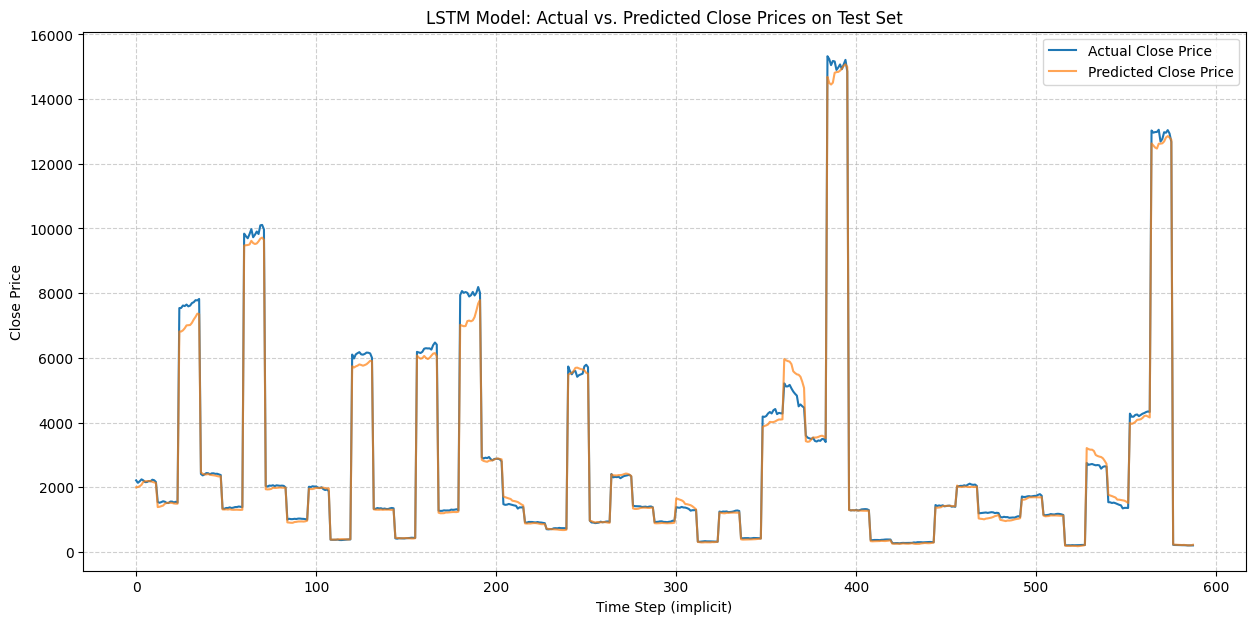

In [42]:
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten()
})

plt.figure(figsize=(15, 7))
plt.plot(plot_df['Actual Close'], label='Actual Close Price')
plt.plot(plot_df['Predicted Close'], label='Predicted Close Price', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [43]:
display(plot_df.head(10))

,Actual Close,Predicted Close
0,2211.8,1996.100098
1,2136.6,2007.088867
2,2184.6,2031.364624
3,2242.9,2074.564453
4,2211.2,2167.398682
5,2156.7,2186.145996
6,2160.8,2188.650391
7,2191.0,2192.291992
8,2183.0,2191.151855
9,2231.7,2165.889404


In [44]:
model.save('lstm_stock_predictor_norm_2lstm_tsip.keras')
print("Trained model saved as 'lstm_stock_predictor.keras'")

Trained model saved as 'lstm_stock_predictor.keras'


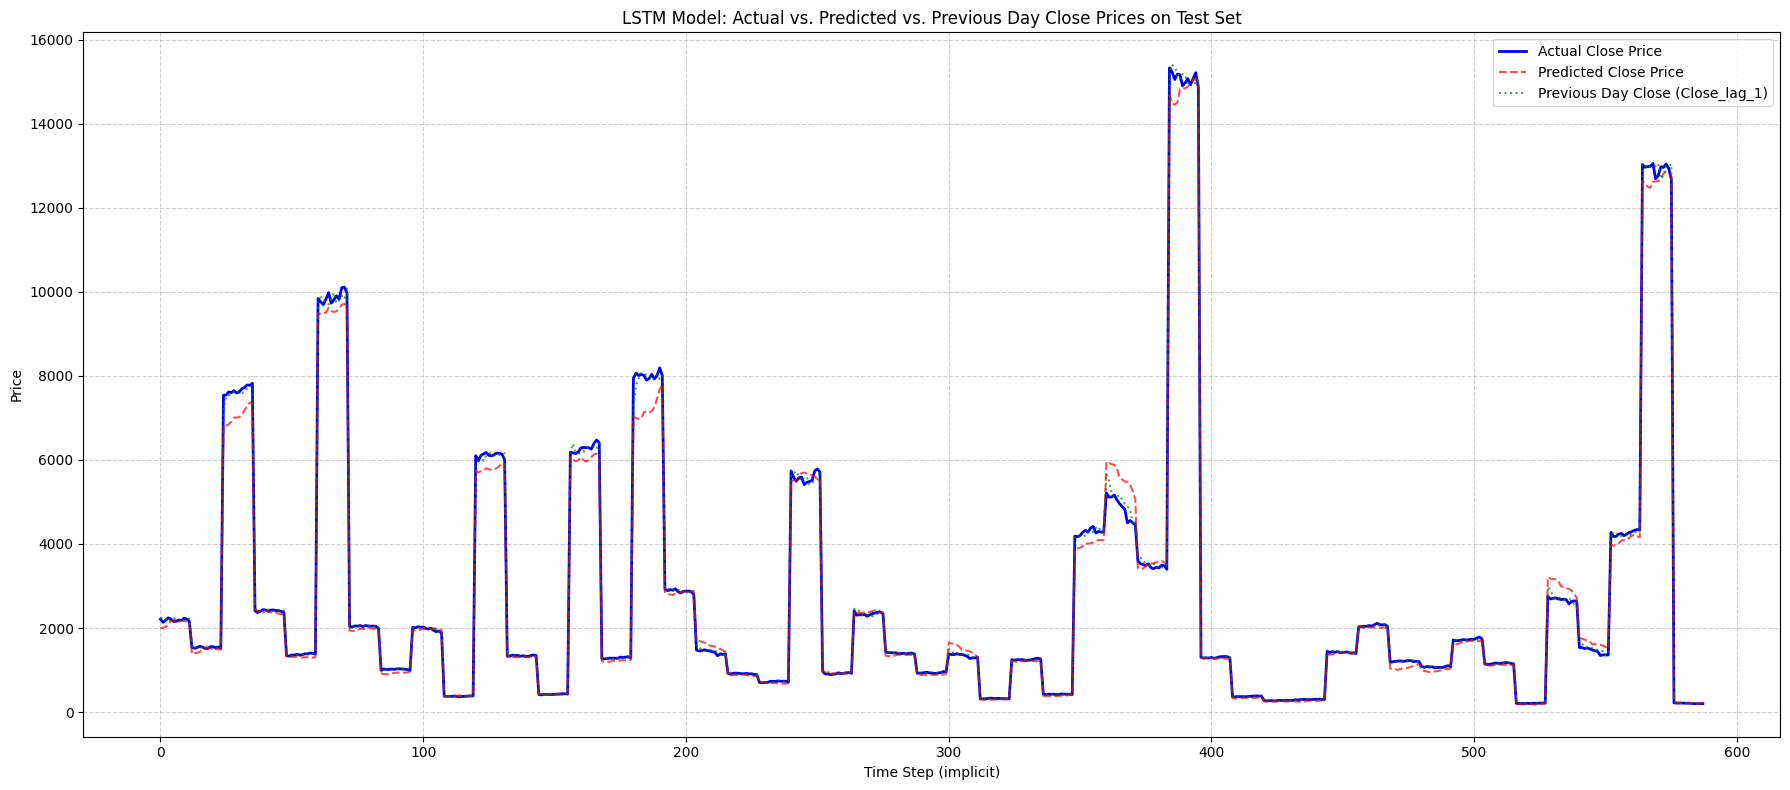

,Actual Close,Predicted Close,Close_lag_1
0,2211.8,1996.100098,2228.4
1,2136.6,2007.088867,2234.4
2,2184.6,2031.364624,2211.8
3,2242.9,2074.564453,2136.6
4,2211.2,2167.398682,2184.6


In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# To inverse transform 'Close_lag_1', we need the full 'columns_to_scale' context from X_test
# First, ensure X_test is a DataFrame (it already is)

# Create a temporary DataFrame with all scaled columns that were used for fitting the scaler
temp_X_test_scaled_for_inverse = X_test[columns_to_scale]

# Inverse transform these columns. This will return a numpy array in the original scale.
original_scale_features = scaler.inverse_transform(temp_X_test_scaled_for_inverse)

# Convert back to DataFrame to easily select the 'Close_lag_1' column, preserving index for potential merges
original_scale_features_df = pd.DataFrame(original_scale_features, columns=columns_to_scale, index=X_test.index)

# Now, extract the inverse-transformed 'Close_lag_1'
inverse_transformed_close_lag_1 = original_scale_features_df['Close_lag_1'].values.flatten()

# Combine the relevant data into a single DataFrame for plotting
combined_plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten(),
    'Close_lag_1': inverse_transformed_close_lag_1
})

plt.figure(figsize=(18, 8))
plt.plot(combined_plot_df['Actual Close'], label='Actual Close Price', color='blue', linewidth=2)
plt.plot(combined_plot_df['Predicted Close'], label='Predicted Close Price', color='red', linestyle='--', alpha=0.7)
plt.plot(combined_plot_df['Close_lag_1'], label='Previous Day Close (Close_lag_1)', color='green', linestyle=':', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted vs. Previous Day Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(combined_plot_df.head())